# 03A — Static one-period model benchmark

This notebook contains the empirical **static one-period benchmark** used in the paper.

It fits three one-period default-count models to the annual ALL, SG, and IG series:

- Torri threshold-type contagion model
- Davis–Lo cumulative-contagion model
- Vasicek common-factor model

The yearly observations are treated as independent conditional on the observed portfolio sizes *n_t*, with common model parameters across years. This is a benchmark analysis; the Probit–Normal environmental framework and its contagion extensions are handled separately in `03B_environmental_models.ipynb`.

## Data policy

The notebook first looks for the proprietary local file

`data/M_1920_2023.csv`

If it is unavailable, it uses

`data/M_1920_2023_synthetic.csv`

generated by `01_generate_synthetic_data.ipynb`.

Synthetic data reproduce only the public workflow and schema; they do **not** reproduce the manuscript's empirical numerical results.

Outputs are written to:

- `pdata/` for numerical tables
- `figure/` for figures

Some model and utility functions are kept inline for now. Functions shared with `02_numerical_experiments.ipynb` and `03B_environmental_models.ipynb` can be moved to `modules/` after the 03-series notebooks are finalized.


In [1]:
# --- ADDED FOR REFACTOR ---
from modules.analysis_helpers import (
    summarize_nt_default,
    summarize_nt_default_by_period,
    to_float_dict
)
# --------------------------

from pathlib import Path
import random
import math

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from IPython.display import display
from math import lgamma
from scipy.optimize import minimize
from scipy.stats import norm, multivariate_normal
from numpy.polynomial.hermite import hermgauss

# ------------------------------------------------------------------
# Project directories
# ------------------------------------------------------------------
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
PDATA_DIR = ROOT / "pdata"
FIGURE_DIR = ROOT / "figure"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PDATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------
SEED = 123
random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------------
# Data selection
# ------------------------------------------------------------------
REAL_DATA = DATA_DIR / "M_1920_2023.csv"
SYNTHETIC_DATA = DATA_DIR / "M_1920_2023_synthetic.csv"

if REAL_DATA.exists():
    DATA_FILE = REAL_DATA
    DATA_SOURCE = "REAL"
    print("=" * 72)
    print("DATA SOURCE: proprietary annual Moody's data")
    print(f"File: {DATA_FILE}")
    print("=" * 72)

elif SYNTHETIC_DATA.exists():
    DATA_FILE = SYNTHETIC_DATA
    DATA_SOURCE = "SYNTHETIC"
    print("=" * 72)
    print("DATA SOURCE: FULLY SYNTHETIC annual default data")
    print("The resulting numerical estimates will NOT reproduce the manuscript.")
    print(f"File: {DATA_FILE}")
    print("=" * 72)

else:
    raise FileNotFoundError(
        "\nNo annual default dataset was found.\n\n"
        "If you have authorized access to the proprietary data, place it at:\n"
        "    data/M_1920_2023.csv\n\n"
        "Otherwise first run:\n"
        "    01_generate_synthetic_data.ipynb\n\n"
        "which should create:\n"
        "    data/M_1920_2023_synthetic.csv\n"
    )

df = pd.read_csv(DATA_FILE)

EXPECTED_COLUMNS = [
    "Year", "ALL", "D_ALL", "SG", "D_SG", "IG", "D_IG"
]
missing = [c for c in EXPECTED_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[EXPECTED_COLUMNS].copy()
df["Year"] = pd.to_numeric(df["Year"], errors="raise").astype(int)

for c in ["ALL", "D_ALL", "SG", "D_SG", "IG", "D_IG"]:
    df[c] = pd.to_numeric(df[c], errors="raise").astype(int)

for cls in ["ALL", "SG", "IG"]:
    if not ((df[cls] > 0) & (df[f"D_{cls}"] >= 0) & (df[f"D_{cls}"] <= df[cls])).all():
        raise ValueError(f"Invalid exposure/default counts for {cls}")

print(f"Rows: {len(df)}")
print(f"Years: {df['Year'].min()}–{df['Year'].max()}")
display(df.head())


DATA SOURCE: proprietary annual Moody's data
File: [LOCAL_REPO_PATH]/data/M_1920_2023.csv
Rows: 104
Years: 1920–2023


,Year,ALL,D_ALL,SG,D_SG,IG,D_IG
0,1920,2674,33,831,25,1843,8
1,1921,2996,32,1163,25,1833,7
2,1922,3277,33,1305,23,1972,10
3,1923,3358,27,1290,22,2068,5
4,1924,3472,40,1297,37,2175,3


## 1. Data summary — Table I inputs

The following cells provide the descriptive statistics used to characterize the annual default-count series before fitting the static benchmark models.


In [2]:
# =========================
# Summary statistics
# =========================


summary = pd.DataFrame([
    summarize_nt_default(df, "ALL"),
    summarize_nt_default(df, "SG"),
    summarize_nt_default(df, "IG"),
])

# Sort order
summary = summary.set_index("Class").loc[["ALL", "SG", "IG"]]

# Display (rounded)
summary_rounded = summary.round({
    "Mean n": 1,
    "Mean L": 2,
    "Mean default rate": 4,
    "Total default rate": 4
})

summary_rounded


summary.to_csv(PDATA_DIR / "table_i_fullsample_summary.csv")
print(f"Saved: {PDATA_DIR / 'table_i_fullsample_summary.csv'}")


Saved: [LOCAL_REPO_PATH]/pdata/table_i_fullsample_summary.csv


In [3]:
# =========================
# Restrict sample period to 1950-2023
# =========================
df_sub = df[(df["Year"] >= 1950) & (df["Year"] <= 2023)].copy()

# Period split
df_sub["period"] = np.where(
    df_sub["Year"] <= 1979,
    "1950-1979",
    "1980-2023"
)


rows = []
for cls in ["ALL", "SG", "IG"]:
    rows.extend(summarize_nt_default_by_period(df_sub, cls))

summary_period = pd.DataFrame(rows)

# Sorting
summary_period = summary_period.set_index(["Class", "Period"]).loc[
    pd.MultiIndex.from_product(
        [["ALL", "SG", "IG"], ["1950-1979", "1980-2023"]],
        names=["Class", "Period"]
    )
]

# Display (rounded)
summary_period_rounded = summary_period.round({
    "Mean n": 1,
    "Mean L": 2,
    "Mean default rate": 4,
    "Total default rate": 4
})

summary_period_rounded


summary_period.to_csv(PDATA_DIR / "table_i_subperiod_summary.csv")
print(f"Saved: {PDATA_DIR / 'table_i_subperiod_summary.csv'}")


Saved: [LOCAL_REPO_PATH]/pdata/table_i_subperiod_summary.csv


## 2. Annual default-rate time series — Fig. 1

This descriptive figure is generated from whichever input file was selected above. With synthetic data, it is only a workflow diagnostic.


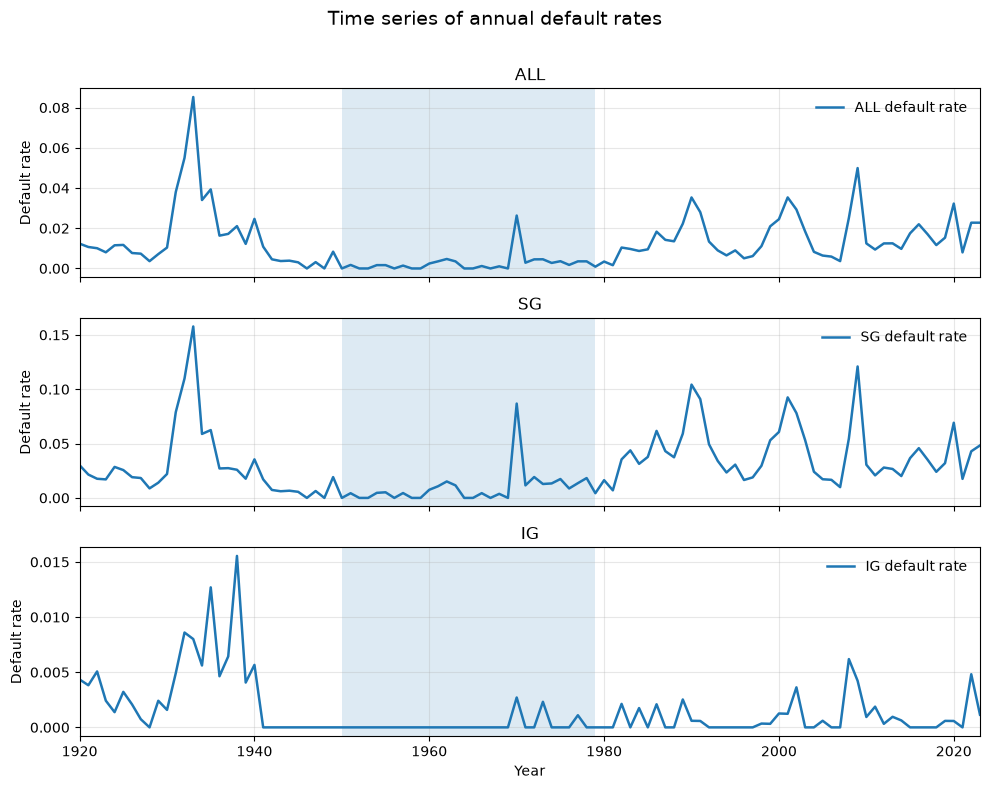

In [4]:
# =========================
# Time-series plot of default rates
#   - 3 panels: ALL / SG / IG
#   - shaded early period: 1950-1979
# =========================

# Required columns:
# df["Year"], df["ALL"], df["D_ALL"], df["SG"], df["D_SG"], df["IG"], df["D_IG"]

# Ensure year is numeric
df["Year"] = pd.to_numeric(df["Year"])

# Construct default rates
for cls in ["ALL", "SG", "IG"]:
    df[f"rate_{cls}"] = df[f"D_{cls}"] / df[cls]

# Plot settings
classes = ["ALL", "SG", "IG"]
titles = {
    "ALL": "ALL",
    "SG": "SG",
    "IG": "IG",
}

fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(10, 8), sharex=True
)

for ax, cls in zip(axes, classes):
    ax.axvspan(1950, 1979, alpha=0.15)

    # Time series
    ax.plot(
        df["Year"],
        df[f"rate_{cls}"],
        linewidth=1.8,
        label=f"{cls} default rate"
    )

    # Styling
    ax.set_ylabel("Default rate")
    ax.set_title(titles[cls], fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, loc="upper right")

axes[-1].set_xlabel("Year")
axes[-1].set_xlim(df["Year"].min(), df["Year"].max())

fig.suptitle("Time series of annual default rates", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
# Save figure
fig.savefig(FIGURE_DIR / "fig1_default_rate_timeseries.pdf", bbox_inches="tight")
plt.show()


## 3. Common numerical utilities

These functions are shared by the three static one-period likelihoods and by the fixed-*n* distributional comparison.


In [5]:
def log_comb(n: int, k: int) -> float:
    return lgamma(n + 1) - lgamma(k + 1) - lgamma(n - k + 1)

def logsumexp_arr(logw: np.ndarray) -> float:
    m = np.max(logw)
    if np.isneginf(m):
        return -np.inf
    return float(m + np.log(np.sum(np.exp(logw - m))))

def logsumexp(x: float, y: float) -> float:
    m = max(x, y)
    if np.isneginf(m):
        return -np.inf
    return float(m + np.log(np.exp(x - m) + np.exp(y - m)))

def logsubexp(a: float, b: float) -> float:
    if b >= a:
        return -np.inf
    return float(a + np.log1p(-np.exp(b - a)))

def normalize_logpmf(logpmf: np.ndarray) -> np.ndarray:
    logpmf = np.where(np.isfinite(logpmf), logpmf, -np.inf)
    m = np.max(logpmf)
    if not np.isfinite(m):
        return np.full_like(logpmf, np.nan, dtype=float)
    z = np.sum(np.exp(logpmf - m))
    return np.exp(logpmf - (m + np.log(z)))

def survival_from_pmf(pmf: np.ndarray) -> np.ndarray:
    pmf = np.asarray(pmf, dtype=float)
    return np.flip(np.cumsum(np.flip(pmf)))

def scaled_counts(n_vals, L_vals, nbar):
    n_vals = np.asarray(n_vals, dtype=float)
    L_vals = np.asarray(L_vals, dtype=float)
    Ls = np.rint(L_vals * (float(nbar) / n_vals)).astype(int)
    return np.maximum(Ls, 0)

def aggregate_m_q_to_rho(m, q):
    den = m * (1.0 - m)
    if den <= 1e-15:
        return float("nan")
    return float((q - m * m) / den)


## 4. Torri threshold-type contagion model

The static maximum-likelihood fit uses the exact one-period Torri default-count likelihood.


In [6]:
def log_pmf_Torri(n: int, h: int, p: float, u: float, v: float) -> float:
    # constraints (p strictly inside to avoid log(0) issues in bc=1-p)
    if not (0.0 < p < 1.0 and 0.0 <= u <= 1.0 and 0.0 <= v <= 1.0):
        return -np.inf
    if not (0 <= h <= n):
        return -np.inf

    a = p*(1.0 - v)
    b = (1.0 - p)*(1.0 - u)
    c = (1.0 - p)*u
    bc = b + c  # = 1-p

    # --- term0 = a^h * (b+c)^(n-h) ---
    # log term0
    if h > 0:
        if a <= 0.0:
            t0 = -np.inf
        else:
            t0 = h*math.log(a) + (n-h)*math.log(bc)
    else:
        # a^0 = 1
        t0 = (n-h)*math.log(bc)

    # --- term1 = ((p+b)^h - (a+b)^h) * c^(n-h) ---
    pb = p + b
    ab = a + b

    if h == 0:
        t1 = -np.inf
    else:
        # if v=0 -> a=p -> pb==ab -> difference 0
        if pb <= 0.0 or ab <= 0.0:
            t1 = -np.inf
        else:
            lp = h*math.log(pb)
            la = h*math.log(ab)

            # stable log(exp(lp)-exp(la)) (requires lp>la)
            diff_log = logsubexp(lp, la)
            if diff_log == -np.inf:
                t1 = -np.inf
            else:
                if (n-h) > 0:
                    if c <= 0.0:
                        t1 = -np.inf
                    else:
                        t1 = diff_log + (n-h)*math.log(c)
                else:
                    t1 = diff_log

    # combine
    inner = logsumexp(t0, t1)
    if inner == -np.inf:
        return -np.inf

    return log_comb(n, h) + inner

def fit_one_Torri(series_n, series_h, x0=None, maxiter=5000):
    data = np.c_[series_n.to_numpy(dtype=int), series_h.to_numpy(dtype=int)]

    def neg_ll_torri(theta):
        # unconstrained -> (0,1) via sigmoid
        p = 1.0/(1.0 + np.exp(-theta[0]))
        u = 1.0/(1.0 + np.exp(-theta[1]))
        v = 1.0/(1.0 + np.exp(-theta[2]))

        ll = 0.0
        for n, h in data:
            lp = log_pmf_Torri(int(n), int(h), float(p), float(u), float(v))
            if not np.isfinite(lp):
                return 1e100
            ll += lp
        return -ll

    # initial guess (logit)
    if x0 is None:
        x0 = np.array([
            math.log(0.01/0.99),  # p ~ 1%
            math.log(0.9/0.1),    # u ~ 0.9
            math.log(0.1/0.9),    # v ~ 0.1
        ], dtype=float)

    res = minimize(neg_ll_torri, x0, method="Nelder-Mead", options={"maxiter": maxiter})

    th = res.x
    p = 1.0/(1.0 + np.exp(-th[0]))
    u = 1.0/(1.0 + np.exp(-th[1]))
    v = 1.0/(1.0 + np.exp(-th[2]))
    return {
        "p": float(p), "u": float(u), "v": float(v),
        "nll": float(res.fun),
        "success": bool(res.success),
        "nit": int(res.nit),
        "message": str(res.message),
    }

# ALL
out_all_Torri = fit_one_Torri(df["ALL"], df["D_ALL"])
print("ALL Torri fit:", out_all_Torri)

# SG / IG
out_sg_Torri = fit_one_Torri(df["SG"], df["D_SG"])
out_ig_Torri = fit_one_Torri(df["IG"], df["D_IG"])
print("SG  Torri fit:", out_sg_Torri)
print("IG  Torri fit:", out_ig_Torri)


ALL Torri fit: {'p': 0.008401151137753948, 'u': 0.980004675944488, 'v': 0.014121693332986157, 'nll': 725.8290833779024, 'success': True, 'nit': 87, 'message': 'Optimization terminated successfully.'}
SG  Torri fit: {'p': 0.0222510616322509, 'u': 0.9524321287077615, 'v': 0.01181877861793521, 'nll': 643.2579759702968, 'success': True, 'nit': 92, 'message': 'Optimization terminated successfully.'}
IG  Torri fit: {'p': 0.0013886154534263142, 'u': 0.5844129082879481, 'v': 6.783619917074998e-14, 'nll': 290.27846864202536, 'success': True, 'nit': 130, 'message': 'Optimization terminated successfully.'}


## 5. Davis–Lo cumulative-contagion model

The static maximum-likelihood fit uses the exact one-period Davis–Lo mixture likelihood.


In [7]:
def logsumexp_vec(logw):
    m = np.max(logw)
    if np.isneginf(m):
        return -np.inf
    return float(m + np.log(np.sum(np.exp(logw - m))))

def log_pmf_LD_1pt(n, h, p, q):
    """
    LD mixture:
      K ~ Bin(n,p)
      L|K=k = k + Bin(n-k, r_k),  r_k = 1 - (1-q)^k
    Return log P(L=h) by summing over k=0..h
    """
    if not (0 <= h <= n):
        return -np.inf

    # numerical guards
    eps = 1e-15
    p = float(np.clip(p, eps, 1.0 - eps))
    q = float(np.clip(q, eps, 1.0 - eps))

    log_p  = math.log(p)
    log_1p = math.log1p(-p)
    log_1q = math.log1p(-q)

    terms = np.full(h+1, -np.inf, dtype=float)

    for k in range(0, h+1):
        t = h - k
        nk = n - k
        if t < 0 or t > nk:
            continue

        # log P(K=k)
        log_pk = log_comb(n, k) + k*log_p + (n-k)*log_1p

        # r_k = 1 - (1-q)^k  (stable)
        if k == 0:
            if t != 0:
                continue
            log_bin = 0.0
        else:
            rk = -math.expm1(k * log_1q)  # stable 1-(1-q)^k
            # handle extreme rk
            if rk <= 0.0:
                if t != 0:
                    continue
                log_bin = 0.0
            elif rk >= 1.0:
                if t != nk:
                    continue
                log_bin = 0.0
            else:
                log_r  = math.log(rk)
                log_1r = math.log1p(-rk)
                log_bin = log_comb(nk, t) + t*log_r + (nk-t)*log_1r

        terms[k] = log_pk + log_bin

    return logsumexp_vec(terms)

def fit_one_LD(series_n, series_h):
    tmp = pd.DataFrame({"n": series_n.to_numpy(dtype=int),
                        "h": series_h.to_numpy(dtype=int)})
    g = tmp.value_counts().reset_index(name="cnt")
    n_arr = g["n"].to_numpy(dtype=int)
    h_arr = g["h"].to_numpy(dtype=int)
    c_arr = g["cnt"].to_numpy(dtype=int)

    def neg_ll_ld(theta):
        p = 1/(1+np.exp(-theta[0]))
        q = 1/(1+np.exp(-theta[1]))

        ll = 0.0
        for n, h, c in zip(n_arr, h_arr, c_arr):
            lp = log_pmf_LD_1pt(int(n), int(h), float(p), float(q))
            if not np.isfinite(lp):
                return 1e100
            ll += c * lp
        return -ll

    x0 = np.array([math.log(0.01/0.99), math.log(0.02/0.98)])
    res = minimize(neg_ll_ld, x0, method="Nelder-Mead", options={"maxiter":8000})

    th = res.x
    p = 1/(1+np.exp(-th[0]))
    q = 1/(1+np.exp(-th[1]))
    return {
        "p": float(p), "q": float(q),
        "nll": float(res.fun),
        "success": bool(res.success),
        "nit": int(res.nit),
        "message": str(res.message),
    }

# quick consistency check
#n = int(df["ALL"].iloc[0])
#p, q = 0.01, 0.02
#pmf = pmf_LD(n, p, q)
#for h in [0, 1, 2, 5, 10]:
#    a = math.log(pmf[h]) if pmf[h] > 0 else -np.inf
#    b = log_pmf_LD_1pt(n, h, p, q)
#    print(h, a, b, a-b)

# Davis-Lo fit dictionaries
out_all_ld = fit_one_LD(df["ALL"], df["D_ALL"])
out_sg_ld  = fit_one_LD(df["SG"],  df["D_SG"])
out_ig_ld  = fit_one_LD(df["IG"],  df["D_IG"])

print("ALL LD fit:", out_all_ld)
print("SG  LD fit:", out_sg_ld)
print("IG  LD fit:", out_ig_ld)


ALL LD fit: {'p': 0.0011255669412148428, 'q': 0.0037846636855538925, 'nll': 461.2161987408968, 'success': True, 'nit': 43, 'message': 'Optimization terminated successfully.'}
SG  LD fit: {'p': 0.002804201013741565, 'q': 0.009240830177675394, 'nll': 441.998261456076, 'success': True, 'nit': 38, 'message': 'Optimization terminated successfully.'}
IG  LD fit: {'p': 0.0004600371841217707, 'q': 0.001014146775969712, 'nll': 194.51755797041162, 'success': True, 'nit': 41, 'message': 'Optimization terminated successfully.'}


## 6. Vasicek common-factor model

The Vasicek likelihood is evaluated with 100-point Gauss–Hermite quadrature, matching the canonical analysis.


In [8]:
# =========================
# Vasicek (GH_N fixed = 100): log P(L_n=h | p, rho_A) + static one-period MLE
# =========================
# p = unconditional default probability

GH_N = 100
gh_x, gh_w = hermgauss(GH_N)

def log_pmf_Vas_1pt(n: int, h: int, p: float, rho_A: float) -> float:
    if not (0 <= h <= n):
        return -np.inf

    eps = 1e-15
    p = float(np.clip(p, eps, 1.0 - eps))
    rho_A = float(np.clip(rho_A, eps, 1.0 - 1e-12))

    a  = norm.ppf(p)
    sr = math.sqrt(rho_A)
    tr = math.sqrt(1.0 - rho_A)

    logC = log_comb(n, h)

    # guard invalid GH weights (should be fine up to ~200, but harmless)
    mask = np.isfinite(gh_w) & (gh_w > 0) & np.isfinite(gh_x)
    x = gh_x[mask]
    w = gh_w[mask]
    if len(w) == 0:
        return -np.inf

    log_terms = np.empty(len(w), dtype=float)

    for i, (xi, wi) in enumerate(zip(x, w)):
        z  = math.sqrt(2.0) * float(xi)
        pi = norm.cdf((a - sr*z) / tr)
        pi = float(np.clip(pi, eps, 1.0 - eps))

        log_bin = logC + h*math.log(pi) + (n-h)*math.log1p(-pi)
        log_terms[i] = math.log(float(wi)) + log_bin

    return logsumexp_vec(log_terms) - 0.5*math.log(math.pi)

def fit_one_Vas(series_n, series_h, x0=None, maxiter=8000):
    tmp = pd.DataFrame({
        "n": series_n.to_numpy(dtype=int),
        "h": series_h.to_numpy(dtype=int),
    })
    g = tmp.value_counts().reset_index(name="cnt")
    n_arr = g["n"].to_numpy(dtype=int)
    h_arr = g["h"].to_numpy(dtype=int)
    c_arr = g["cnt"].to_numpy(dtype=int)

    def neg_ll_vas(theta):
        p     = 1.0/(1.0 + np.exp(-theta[0]))
        rho_A = 1.0/(1.0 + np.exp(-theta[1]))

        ll = 0.0
        for n, h, c in zip(n_arr, h_arr, c_arr):
            lp = log_pmf_Vas_1pt(int(n), int(h), float(p), float(rho_A))
            if not np.isfinite(lp):
                return 1e100
            ll += int(c) * lp
        return -ll

    if x0 is None:
        x0 = np.array([math.log(0.01/0.99), math.log(0.05/0.95)], dtype=float)

    res = minimize(neg_ll_vas, x0, method="Nelder-Mead", options={"maxiter": maxiter})

    th = res.x
    p     = 1.0/(1.0 + np.exp(-th[0]))
    rho_A = 1.0/(1.0 + np.exp(-th[1]))

    return {
        "p": float(p),
        "rho_A": float(rho_A),
        "nll": float(res.fun),
        "success": bool(res.success),
        "nit": int(res.nit),
        "message": str(res.message),
        "GH_N": int(GH_N),
    }

# ---- fits ----
out_all_vas = fit_one_Vas(df["ALL"], df["D_ALL"])
out_sg_vas  = fit_one_Vas(df["SG"],  df["D_SG"])
out_ig_vas  = fit_one_Vas(df["IG"],  df["D_IG"])

print("ALL Vasicek fit:", out_all_vas)
print("SG  Vasicek fit:", out_sg_vas)
print("IG  Vasicek fit:", out_ig_vas)


ALL Vasicek fit: {'p': 0.011775206606779358, 'rho_A': 0.13557728347067463, 'nll': 431.3637107991922, 'success': True, 'nit': 35, 'message': 'Optimization terminated successfully.', 'GH_N': 100}
SG  Vasicek fit: {'p': 0.030365528141289545, 'rho_A': 0.14959676685401402, 'nll': 417.7085349993006, 'success': True, 'nit': 45, 'message': 'Optimization terminated successfully.', 'GH_N': 100}
IG  Vasicek fit: {'p': 0.0016138196765759921, 'rho_A': 0.2000063051072147, 'nll': 182.38168605536433, 'success': True, 'nit': 35, 'message': 'Optimization terminated successfully.', 'GH_N': 100}


## 7. Static maximum-likelihood fit summary

This table collects the raw fitted parameters and negative log-likelihood values before constructing the paper-style Table II.


In [9]:
# =========================
# Summary table: Torri / LD / Vas(GH_N=100)
# =========================


rows = []

# --- Torri ---
rows.append({**{"model":"Torri", "class":"ALL"}, **to_float_dict(out_all_Torri)})
rows.append({**{"model":"Torri", "class":"SG"},  **to_float_dict(out_sg_Torri)})
rows.append({**{"model":"Torri", "class":"IG"},  **to_float_dict(out_ig_Torri)})

# --- LD ---
rows.append({**{"model":"Davis-Lo", "class":"ALL"}, **to_float_dict(out_all_ld)})
rows.append({**{"model":"Davis-Lo", "class":"SG"},  **to_float_dict(out_sg_ld)})
rows.append({**{"model":"Davis-Lo", "class":"IG"},  **to_float_dict(out_ig_ld)})

# --- Vasicek (GH_N=100) ---
rows.append({**{"model":"Vasicek", "class":"ALL"}, **to_float_dict(out_all_vas)})
rows.append({**{"model":"Vasicek", "class":"SG"},  **to_float_dict(out_sg_vas)})
rows.append({**{"model":"Vasicek", "class":"IG"},  **to_float_dict(out_ig_vas)})

df_fit = pd.DataFrame(rows)

# column order (missing columns are ignored)
col_order = [
    "model","class","nll",
    "p","u","v",
    "q",
    "rho_A",
    "success","nit","message","GH_N"
]
df_fit = df_fit[[c for c in col_order if c in df_fit.columns]]

# nice sorting
df_fit = df_fit.sort_values(["class","model"]).reset_index(drop=True)

df_fit.round(6)


df_fit.to_csv(PDATA_DIR / "static_fit_parameters_raw.csv", index=False)
print(f"Saved: {PDATA_DIR / 'static_fit_parameters_raw.csv'}")


Saved: [LOCAL_REPO_PATH]/pdata/static_fit_parameters_raw.csv


## 8. Implied moments and manuscript Table II

For the empirical rows, the mean default probability *m* and pairwise default correlation *rho* are computed from annual counts using obligor and obligor-pair weighting.

For each fitted model, the corresponding one-period moments are aggregated over the observed annual portfolio sizes using the same weighting scheme.


In [10]:
def moments_from_params_Torri(n: int, p: float, u: float, v: float):
    b = (1.0 - p) * (1.0 - u)
    s = 1.0 - p * v
    m = p + b * (1.0 - s ** (n - 1))
    a_alt = s + p - 1.0
    s_pow = s ** (n - 2) if n > 2 else 1.0
    pair = (p + b) ** 2 - b * (2.0 * a_alt + b) * s_pow
    cov = pair - m ** 2
    den = m * (1.0 - m)
    rho = np.nan if den <= 1e-15 else cov / den
    return float(m), float(rho)

def m_rho_LD(n: int, p: float, q: float):
    m = 1.0 - (1.0 - p) * (1.0 - q * p) ** (n - 1)
    if n < 2:
        return float(m), np.nan

    cov = (1.0 - p) ** 2 * (
        (1.0 - 2.0 * p * q + p * q ** 2) ** (n - 2)
        - (1.0 - p * q) ** (2 * (n - 1))
    )
    den = m * (1.0 - m)
    rho = np.nan if den <= 1e-15 else cov / den
    return float(m), float(rho)

def phi2_aa(a: float, rhoA: float) -> float:
    cov = np.array([[1.0, rhoA], [rhoA, 1.0]], dtype=float)
    return float(multivariate_normal.cdf([a, a], mean=[0.0, 0.0], cov=cov))

def data_m_q_hat(n_vals, L_vals):
    n = np.asarray(n_vals, dtype=float)
    L = np.asarray(L_vals, dtype=float)

    m_hat = np.sum(L) / np.sum(n)

    pair_weight = n * (n - 1.0)
    denom = np.sum(pair_weight)
    q_hat = (
        np.sum(L * (L - 1.0)) / denom
        if denom > 0
        else float("nan")
    )
    rho_hat = aggregate_m_q_to_rho(m_hat, q_hat)
    return float(m_hat), float(q_hat), float(rho_hat)

def model_aggregate_m_q(n_vals, m_q_fn):
    n = np.asarray(n_vals, dtype=int)
    uniq, cnt = np.unique(n, return_counts=True)

    sum_n = float(np.sum(uniq * cnt))
    sum_pair = float(np.sum(uniq * (uniq - 1) * cnt))

    num_m = 0.0
    num_q = 0.0

    for nn, cc in zip(uniq, cnt):
        if nn <= 0:
            continue

        m_n, q_n = m_q_fn(int(nn))
        num_m += float(cc) * float(nn) * float(m_n)

        if nn >= 2:
            num_q += float(cc) * float(nn) * float(nn - 1) * float(q_n)

    m = num_m / sum_n if sum_n > 0 else float("nan")
    q = num_q / sum_pair if sum_pair > 0 else float("nan")
    rho = aggregate_m_q_to_rho(m, q)

    return float(m), float(q), float(rho)

def torri_m_q_fn(p, u, v):
    def _fn(n):
        m_n, rho_n = moments_from_params_Torri(n, p, u, v)
        q_n = (
            m_n * m_n + rho_n * m_n * (1.0 - m_n)
            if np.isfinite(rho_n)
            else float("nan")
        )
        return float(m_n), float(q_n)
    return _fn

def ld_m_q_fn(p, q):
    def _fn(n):
        m_n, rho_n = m_rho_LD(n, p, q)
        q_n = (
            m_n * m_n + rho_n * m_n * (1.0 - m_n)
            if np.isfinite(rho_n)
            else float("nan")
        )
        return float(m_n), float(q_n)
    return _fn

def vas_m_q_fn(p, rhoA):
    a = norm.ppf(p)
    q_pair = phi2_aa(a, rhoA)

    def _fn(n):
        return float(p), float(q_pair)

    return _fn


In [11]:
fits_torri = {
    "ALL": out_all_Torri,
    "SG": out_sg_Torri,
    "IG": out_ig_Torri,
}
fits_ld = {
    "ALL": out_all_ld,
    "SG": out_sg_ld,
    "IG": out_ig_ld,
}
fits_vas = {
    "ALL": out_all_vas,
    "SG": out_sg_vas,
    "IG": out_ig_vas,
}

moment_rows = []

for key in ["ALL", "SG", "IG"]:
    n_vals = df[key].to_numpy(dtype=int)
    L_vals = df[f"D_{key}"].to_numpy(dtype=int)

    m_emp, q_emp, rho_emp = data_m_q_hat(n_vals, L_vals)

    ft = fits_torri[key]
    fld = fits_ld[key]
    fv = fits_vas[key]

    m_t, q_t, rho_t = model_aggregate_m_q(
        n_vals,
        torri_m_q_fn(ft["p"], ft["u"], ft["v"]),
    )
    m_ld, q_ld, rho_ld = model_aggregate_m_q(
        n_vals,
        ld_m_q_fn(fld["p"], fld["q"]),
    )
    m_v, q_v, rho_v = model_aggregate_m_q(
        n_vals,
        vas_m_q_fn(fv["p"], fv["rho_A"]),
    )

    moment_rows.extend([
        {
            "class": key,
            "source": "Data",
            "nll": np.nan,
            "p": np.nan,
            "dep_param": "",
            "m": m_emp,
            "rho": rho_emp,
        },
        {
            "class": key,
            "source": "Torri",
            "nll": ft["nll"],
            "p": ft["p"],
            "dep_param": f"u={ft['u']:.6g}, v={ft['v']:.6g}",
            "m": m_t,
            "rho": rho_t,
        },
        {
            "class": key,
            "source": "Vasicek",
            "nll": fv["nll"],
            "p": fv["p"],
            "dep_param": f"rho_A={fv['rho_A']:.6g}",
            "m": m_v,
            "rho": rho_v,
        },
        {
            "class": key,
            "source": "Davis–Lo",
            "nll": fld["nll"],
            "p": fld["p"],
            "dep_param": f"q={fld['q']:.6g}",
            "m": m_ld,
            "rho": rho_ld,
        },
    ])

table_ii = pd.DataFrame(moment_rows)

source_order = pd.CategoricalDtype(
    ["Data", "Torri", "Vasicek", "Davis–Lo"],
    ordered=True,
)
class_order = pd.CategoricalDtype(
    ["ALL", "IG", "SG"],
    ordered=True,
)

table_ii["source"] = table_ii["source"].astype(source_order)
table_ii["class"] = table_ii["class"].astype(class_order)

table_ii = (
    table_ii
    .sort_values(["class", "source"])
    .reset_index(drop=True)
)

display(
    table_ii.assign(
        nll=table_ii["nll"].round(3),
        p=table_ii["p"].round(6),
        m=table_ii["m"].round(6),
        rho=table_ii["rho"].round(6),
    )
)

table_ii.to_csv(PDATA_DIR / "table_ii_static_model_fit.csv", index=False)
print(f"Saved: {PDATA_DIR / 'table_ii_static_model_fit.csv'}")

# ------------------------------------------------------------------
# Manuscript-value audit: only meaningful for the proprietary data.
# ------------------------------------------------------------------
if DATA_SOURCE == "REAL":
    expected_nll = {
        ("ALL", "Torri"): 725.8290833779024,
        ("ALL", "Vasicek"): 431.3637107991922,
        ("ALL", "Davis–Lo"): 461.2161987408968,
        ("IG", "Torri"): 290.27846864202536,
        ("IG", "Vasicek"): 182.38168605536433,
        ("IG", "Davis–Lo"): 194.51755797041162,
        ("SG", "Torri"): 643.2579759702968,
        ("SG", "Vasicek"): 417.7085349993006,
        ("SG", "Davis–Lo"): 441.998261456076,
    }

    max_abs_diff = 0.0

    for (cls, model), expected in expected_nll.items():
        observed = float(
            table_ii.loc[
                (table_ii["class"].astype(str) == cls)
                & (table_ii["source"].astype(str) == model),
                "nll",
            ].iloc[0]
        )
        max_abs_diff = max(max_abs_diff, abs(observed - expected))

    print(f"Maximum NLL difference from canonical static fit: {max_abs_diff:.6g}")
    print(
        "Static Table II NLL audit:",
        "PASS" if max_abs_diff < 1e-4 else "REVIEW"
    )
else:
    print("Manuscript-value audit skipped for synthetic data.")


,class,source,nll,p,dep_param,m,rho
0,ALL,Data,NaN,NaN,,0.015664,0.011336
1,ALL,Torri,725.829,0.008401,"u=0.980005, v=0.0141217",0.015668,0.009577
2,ALL,Vasicek,431.364,0.011775,rho_A=0.135577,0.011775,0.015423
3,ALL,Davis–Lo,461.216,0.001126,q=0.00378466,0.018323,0.016055
4,IG,Data,NaN,NaN,,0.001389,0.001910
5,IG,Torri,290.278,0.001389,"u=0.584413, v=6.78362e-14",0.001389,0.000000
6,IG,Vasicek,182.382,0.001614,rho_A=0.200006,0.001614,0.007979
7,IG,Davis–Lo,194.518,0.000460,q=0.00101415,0.001569,0.002013
8,SG,Data,NaN,NaN,,0.037835,0.022022
9,SG,Torri,643.258,0.022251,"u=0.952432, v=0.0118188",0.038743,0.023627


Saved: [LOCAL_REPO_PATH]/pdata/table_ii_static_model_fit.csv
Maximum NLL difference from canonical static fit: 0
Static Table II NLL audit: PASS


## 9. Fixed-*n* distributional comparison — Fig. 2

The models are fitted using the observed annual portfolio sizes *n_t*. For visualization, the annual counts are rescaled to the sample-mean portfolio size for each class.

The current manuscript Fig. 2 compares ALL and IG using:

- PMFs in the top row;
- survival functions on a logarithmic scale in the bottom row.

The synthetic-data version is only a workflow check.


In [12]:
NBAR = {
    key: int(round(df[key].mean()))
    for key in ["ALL", "SG", "IG"]
}

def model_pmf_fixed_n(model, key, nbar, hmax):
    h = np.arange(hmax + 1, dtype=int)
    logp = np.full(hmax + 1, -np.inf, dtype=float)
    h_ok = h[h <= nbar]

    if model == "Torri":
        f = fits_torri[key]
        logp[h_ok] = np.array([
            log_pmf_Torri(
                int(nbar), int(x),
                float(f["p"]), float(f["u"]), float(f["v"])
            )
            for x in h_ok
        ])

    elif model == "Davis-Lo":
        f = fits_ld[key]
        logp[h_ok] = np.array([
            log_pmf_LD_1pt(
                int(nbar), int(x),
                float(f["p"]), float(f["q"])
            )
            for x in h_ok
        ])

    elif model == "Vasicek":
        f = fits_vas[key]
        logp[h_ok] = np.array([
            log_pmf_Vas_1pt(
                int(nbar), int(x),
                float(f["p"]), float(f["rho_A"])
            )
            for x in h_ok
        ])

    else:
        raise ValueError(f"Unknown model: {model}")

    return normalize_logpmf(logp)

def empirical_fixed_n_pmf(key):
    nbar = NBAR[key]
    n_vals = df[key].to_numpy(dtype=int)
    L_vals = df[f"D_{key}"].to_numpy(dtype=int)

    Ls = scaled_counts(n_vals, L_vals, nbar)
    hmax = int(Ls.max())
    h = np.arange(hmax + 1, dtype=int)

    hist, _ = np.histogram(
        Ls,
        bins=np.arange(hmax + 2) - 0.5,
        density=True,
    )
    pmf = np.maximum(hist, 0.0)
    pmf = pmf / pmf.sum()

    return h, pmf

mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 1.9,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


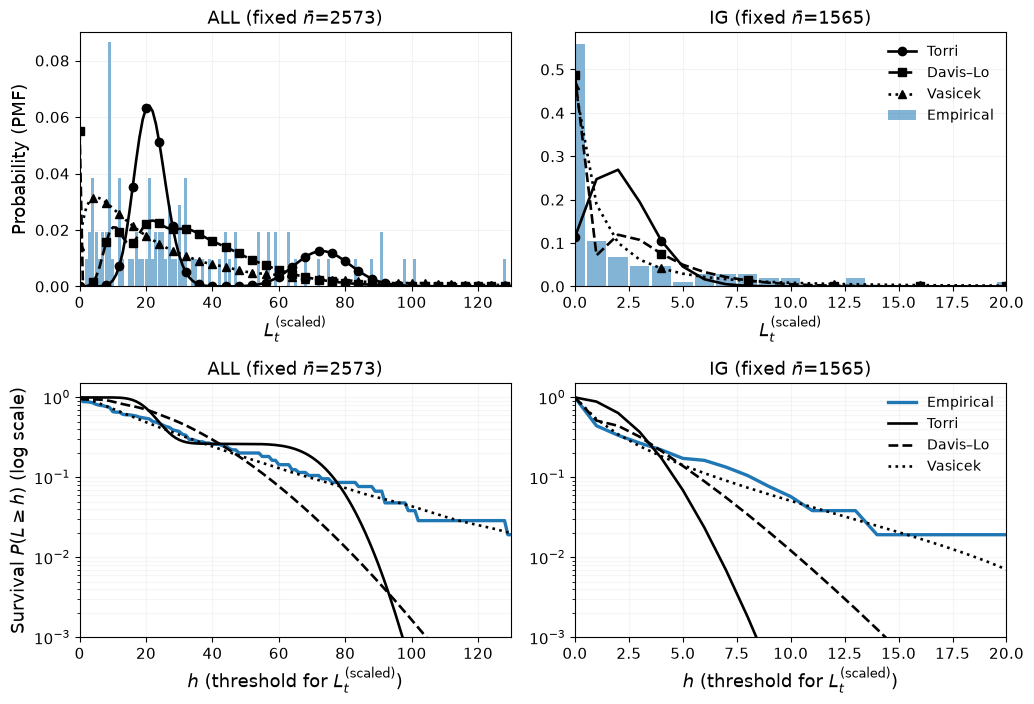

Saved: [LOCAL_REPO_PATH]/figure/fig2_static_benchmark_ALL_IG.pdf


In [13]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(10.5, 7.2),
    sharex=False,
    sharey=False,
)

classes = ["ALL", "IG"]

for j, key in enumerate(classes):
    h, pmf_data = empirical_fixed_n_pmf(key)
    hmax = int(h[-1])
    nbar = NBAR[key]

    pmf_t = model_pmf_fixed_n("Torri", key, nbar, hmax)
    pmf_ld = model_pmf_fixed_n("Davis-Lo", key, nbar, hmax)
    pmf_v = model_pmf_fixed_n("Vasicek", key, nbar, hmax)

    # --------------------------------------------------------------
    # Top row: PMFs
    # --------------------------------------------------------------
    ax = axes[0, j]

    ax.bar(
        h,
        pmf_data,
        width=0.9,
        alpha=0.55,
        linewidth=0.4,
        label="Empirical",
    )
    ax.plot(h, pmf_t, color="black", marker="o", markevery=4, label="Torri")
    ax.plot(h, pmf_ld, color="black", linestyle="--", marker="s", markevery=4, label="Davis–Lo")
    ax.plot(h, pmf_v, color="black", linestyle=":", marker="^", markevery=4, label="Vasicek")

    ax.set_title(f"{key} (fixed $\\bar{{n}}$={nbar})")
    ax.set_xlabel(r"$L_t^{(\mathrm{scaled})}$")
    ax.set_ylabel("Probability (PMF)")
    ax.grid(alpha=0.15)

    if key == "ALL":
        ax.set_xlim(0, 130)
        ax.set_ylim(0, 0.09)
    else:
        ax.set_xlim(0, 20)

    if key == "IG":
        ax.legend(frameon=False, loc="upper right")

    # --------------------------------------------------------------
    # Bottom row: survival functions
    # --------------------------------------------------------------
    ax = axes[1, j]

    eps = 1e-12

    curves = {
        "Empirical": survival_from_pmf(pmf_data),
        "Torri": survival_from_pmf(pmf_t),
        "Davis-Lo": survival_from_pmf(pmf_ld),
        "Vasicek": survival_from_pmf(pmf_v),
    }

    ax.plot(h, np.maximum(curves["Empirical"], eps), label="Empirical", linewidth=2.4)
    ax.plot(h, np.maximum(curves["Torri"], eps), color="black", label="Torri")
    ax.plot(h, np.maximum(curves["Davis-Lo"], eps), color="black", linestyle="--", label="Davis–Lo")
    ax.plot(h, np.maximum(curves["Vasicek"], eps), color="black", linestyle=":", label="Vasicek")

    ax.set_yscale("log")
    ax.set_title(f"{key} (fixed $\\bar{{n}}$={nbar})")
    ax.set_xlabel(r"$h$ (threshold for $L_t^{(\mathrm{scaled})}$)")
    ax.set_ylabel(r"Survival $P(L \geq h)$ (log scale)")
    ax.grid(alpha=0.12, which="both")
    ax.set_ylim(1e-3, 1.5)

    if key == "ALL":
        ax.set_xlim(0, 130)
    else:
        ax.set_xlim(0, 20)

    if key == "IG":
        ax.legend(frameon=False, loc="upper right")

axes[0, 1].set_ylabel("")
axes[1, 1].set_ylabel("")

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "fig2_static_benchmark_ALL_IG.pdf",
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "fig2_static_benchmark_ALL_IG.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {FIGURE_DIR / 'fig2_static_benchmark_ALL_IG.pdf'}")


## Output summary

A complete run writes the following main public artifacts.

### `pdata/`

- `table_i_fullsample_summary.csv`
- `table_i_subperiod_summary.csv`
- `static_fit_parameters_raw.csv`
- `table_ii_static_model_fit.csv`

### `figure/`

- `fig1_default_rate_timeseries.pdf`
- `fig2_static_benchmark_ALL_IG.pdf`
- `fig2_static_benchmark_ALL_IG.png`

With the proprietary annual data, the static-fit NLL audit checks the canonical Table II fit. With synthetic data, that manuscript-value audit is skipped automatically.

The Probit–Normal environmental null M0 and its contagion extensions M1/M2 belong to `03B_environmental_models.ipynb`.
